#Импорт библиотек и загрузка датасетов

In [44]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.simplefilter(action='ignore', category=FutureWarning)

In [45]:
files = {
    "yellow": "D:/Pet_projekts/realty/yellow.csv",
    "red": "D:/Pet_projekts/realty/red.csv",

}

dfs = {name: pd.read_csv(path) for name, path in files.items()}

dfy = dfs["yellow"]
dfr = dfs["red"]

In [46]:
dfy = dfy.drop(columns=["uuid","code","url","title","price_currency","storey","storeys","contact_name","contact_phones","photo","description", "town_name", "state_region", "state_district"], errors="ignore")

In [47]:
dfr = dfr.drop(columns=["resale","photo","id","url", "latitude", "longitude"], errors="ignore") #сразу удаляем лишние колонки (внутренние id, ссылки, фото, персональные данные)

In [48]:
dfy.head(1)

,price,price_usd,price_byn,price_per_m2,rooms,area_total,area_living,area_kitchen,address,street_name,house_number,metro_station,metro_time,building_year,wall_material,repair_state,agency_name,created_at,updated_at
0,110250,110250,333903,2250,1,49.0,49.0,NaN,Минск Лосика ул. 47,Лосика ул.,47.0,NaN,NaN,2026,NaN,8.0,NaN,2026-07-13T18:05:25+03:00,2026-09-01T16:46:06+03:00


In [49]:
dfr.head(1)

,price_amount,price_currency,price_usd,price_byn,number_of_rooms,floor,number_of_floors,area_total,area_living,area_kitchen,address,user_address,seller_type,created_at,last_time_up,auction_bid_amount,auction_bid_currency
0,291403.0,BYN,96217.06,291403.0,1,3,22,31.3,24.2,NaN,"Минск, Братская ул. 8","Минск, Братская ул. 8",agent,2026-08-22T14:55:00+03:00,2026-09-15T11:15:09+03:00,3.0,BYN


#EDA - Разведывательный анализ данных

## Первый датасет

In [50]:
dfy.isna().sum() #пропущенные значения в таблице

price               0
price_usd           0
price_byn           0
price_per_m2        0
rooms               0
area_total          0
area_living      1424
area_kitchen     2951
address             0
street_name         0
house_number       63
metro_station    1799
metro_time       3107
building_year       0
wall_material    3688
repair_state     1516
agency_name       341
created_at          0
updated_at          0
dtype: int64

In [51]:
dfy = dfy.drop(columns=['wall_material', 'metro_time']) # дополнительно удаляем колонки с большим количеством незаполненных значений

In [52]:
print('Дубликатов =', dfy.duplicated().sum())

Дубликатов = 3


In [53]:
dfy = dfy.drop_duplicates() # удаляем дубликаты

In [54]:
dfy.info() # информация о данных в датафрейме: сколько строк, какие данные в столбцах, сколько пропущенных значений

<class 'pandas.DataFrame'>
Index: 3685 entries, 0 to 3687
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          3685 non-null   int64  
 1   price_usd      3685 non-null   int64  
 2   price_byn      3685 non-null   int64  
 3   price_per_m2   3685 non-null   int64  
 4   rooms          3685 non-null   int64  
 5   area_total     3685 non-null   float64
 6   area_living    2264 non-null   float64
 7   area_kitchen   737 non-null    float64
 8   address        3685 non-null   str    
 9   street_name    3685 non-null   str    
 10  house_number   3622 non-null   float64
 11  metro_station  1889 non-null   str    
 12  building_year  3685 non-null   int64  
 13  repair_state   2172 non-null   float64
 14  agency_name    3344 non-null   str    
 15  created_at     3685 non-null   str    
 16  updated_at     3685 non-null   str    
dtypes: float64(5), int64(6), str(6)
memory usage: 1.1 MB


In [55]:
cat_columnsy = [] # создаем пустой список для имен колонок категориальных данных
num_columnsy = [] # создаем пустой список для имен колонок числовых данных

for column_name in dfy.columns: # смотрим на все колонки в датафрейме
    if (dfy[column_name].dtypes == object): # проверяем тип данных для каждой колонки
        cat_columnsy +=[column_name] # если тип объект - то складываем в категориальные данные
    else:
        num_columnsy +=[column_name] # иначе - числовые


# выводим результат
print('Категориальные данные:\t ',cat_columnsy, '\n Число столблцов = ',len(cat_columnsy))

print('Числовые данные:\t ',  num_columnsy, '\n Число столблцов = ',len(num_columnsy))

Категориальные данные:	  [] 
 Число столблцов =  0
Числовые данные:	  ['price', 'price_usd', 'price_byn', 'price_per_m2', 'rooms', 'area_total', 'area_living', 'area_kitchen', 'address', 'street_name', 'house_number', 'metro_station', 'building_year', 'repair_state', 'agency_name', 'created_at', 'updated_at'] 
 Число столблцов =  17


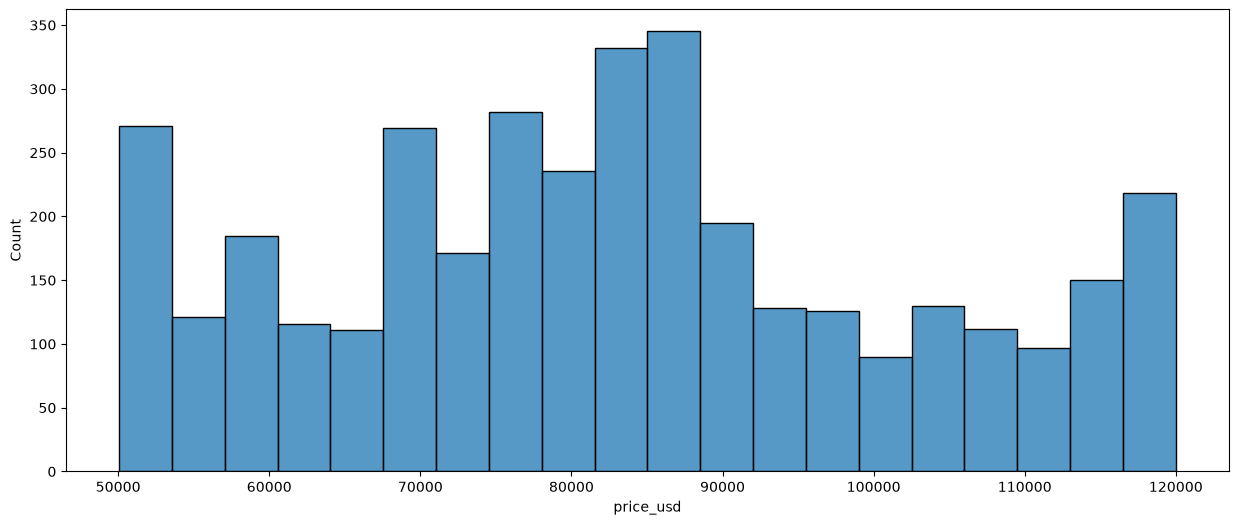

In [56]:
# Порядок распределения цен

plt.figure(figsize=(15,6)) # создаем "полотно", уточняем размер
sns.histplot(data=dfy, # какой датафрейм используем
             x='price_usd', # какую переменную отрисовываем
             bins = 20, # на сколько ячеек разбиваем
             log_scale = False); # захотели использовать логарифмический масштаб (для очень больших диапазонов)

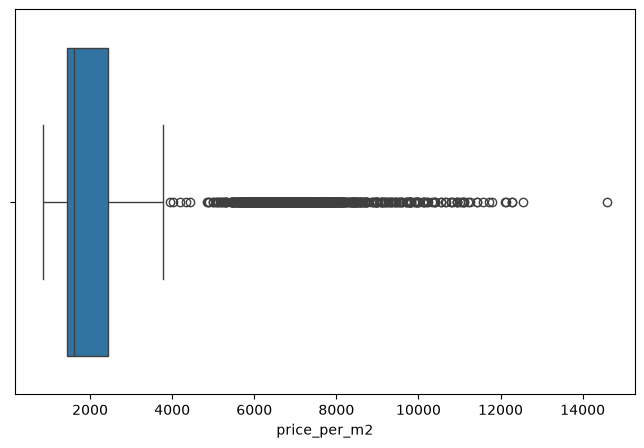

In [57]:
# разброс цен за м2

plt.figure(figsize=(8, 5))
sns.boxplot(data=dfy, x="price_per_m2")
plt.show()

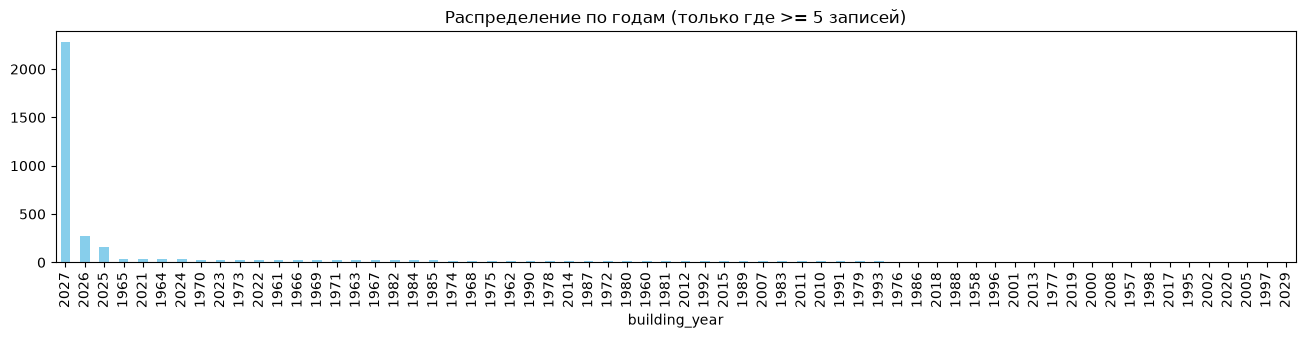

In [58]:
# График распределения по годам постройки

counts = dfy['building_year'].value_counts()

counts_filtered = counts[counts >= 5]

plt.figure(figsize=(16, 3))
counts_filtered.plot(kind='bar', color='skyblue')
plt.title('Распределение по годам (только где >= 5 записей)')
plt.show()

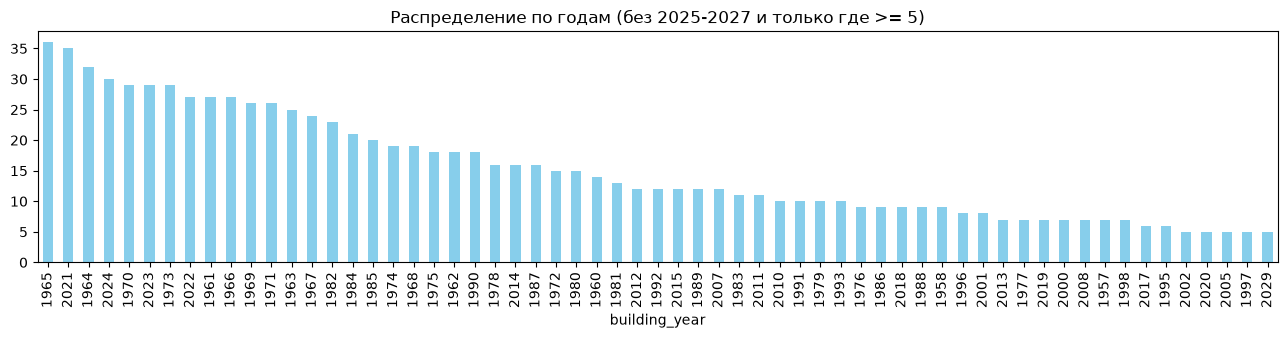

In [59]:
# Убираем новостройки 2025-27 гг

counts = dfy['building_year'].value_counts()

counts_filtered = counts[~counts.index.isin([2025, 2026, 2027])]
counts_filtered = counts_filtered[counts_filtered >= 5]

plt.figure(figsize=(16, 3))
counts_filtered.plot(kind='bar', color='skyblue')
plt.title('Распределение по годам (без 2025-2027 и только где >= 5)')
plt.show()

In [60]:
#Итоговое количество объектов после чистки

total_objects = counts_filtered.sum()

print("Сколько объектов попало (суммарно):", total_objects)

Сколько объектов попало (суммарно): 932


In [61]:
# Распределение по агенствам

res = (dfy['agency_name']
       .value_counts(dropna=False)
       .reset_index(name='count')
       .rename(columns={'index': 'agency_name'}))

pd.set_option('display.max_rows', None)
print(res)


                                     agency_name  count
0                                        Бир Бай   1415
1       Международная риэлтерская компания ЭТАЖИ   1156
2                                            NaN    341
3                 Агентство недвижимости Мариэлт     56
4          Агентство недвижимости «Твоя столица»     52
5                              Бриллиантовый лев     45
6                                  Фаттория Плюс     39
7                                Квадратный метр     36
8                            ТВОЯ СТОЛИЦАконсалт     30
9                                    АН Фаттория     26
10                                      7 этажей     25
11                                       Мольнар     25
12                           Резалт Недвижимость     22
13                            Альфа-Недвижимость     21
14                                        Алькор     20
15       Центр международной недвижимости Моя 7Я     18
16                     Риэлтерский центр Столицы

In [62]:
# Меняем содержание столбца агенства (все агенты теперь не делятся по кампаниям и появляется собственник)

dfy["agency_name"] = np.where(dfy["agency_name"].isna(), "owner", "agent")

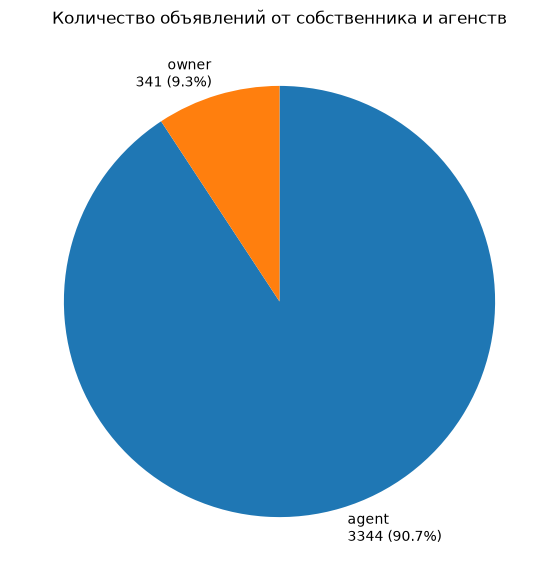

In [63]:
# Сравнение количества объявлений от агенств и собственника

plt.figure(figsize=(7, 7))

counts = dfy["agency_name"].value_counts(dropna=False)
total = counts.sum()

labels = counts.index.astype(str)
sizes = counts.values
percents = (sizes / total * 100).round(1)

plt.pie(
    sizes,
    labels=[f"{lab}\n{cnt} ({pct}%)" for lab, cnt, pct in zip(labels, sizes, percents)],
    startangle=90,
    counterclock=False
)

plt.title("Количество объявлений от собственника и агенств")
plt.show()

##Второй датасет

In [64]:
dfr.isna().sum() #пропущенные значения в таблице

price_amount              0
price_currency            0
price_usd                 0
price_byn                 0
number_of_rooms           0
floor                     0
number_of_floors          0
area_total                0
area_living               0
area_kitchen            197
address                  69
user_address              0
seller_type               0
created_at                0
last_time_up              0
auction_bid_amount      919
auction_bid_currency    919
dtype: int64

In [65]:
dfr = dfr.drop(columns=['auction_bid_amount', 'auction_bid_currency']) # дополнительно удаляем колонки с большим количеством незаполненных значений

In [66]:
print('Дубликатов =', dfr.duplicated().sum())

Дубликатов = 0


In [67]:
#dfr = dfy.drop_duplicates() # удаляем дубликаты

In [68]:
dfr.info() # информация о данных в датафрейме: сколько строк, какие данные в столбцах, сколько пропущенных значений

<class 'pandas.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price_amount      924 non-null    float64
 1   price_currency    924 non-null    str    
 2   price_usd         924 non-null    float64
 3   price_byn         924 non-null    float64
 4   number_of_rooms   924 non-null    int64  
 5   floor             924 non-null    int64  
 6   number_of_floors  924 non-null    int64  
 7   area_total        924 non-null    float64
 8   area_living       924 non-null    float64
 9   area_kitchen      727 non-null    float64
 10  address           855 non-null    str    
 11  user_address      924 non-null    str    
 12  seller_type       924 non-null    str    
 13  created_at        924 non-null    str    
 14  last_time_up      924 non-null    str    
dtypes: float64(6), int64(3), str(6)
memory usage: 244.4 KB


In [69]:
cat_columnsr = [] # создаем пустой список для имен колонок категориальных данных
num_columnsr = [] # создаем пустой список для имен колонок числовых данных

for column_name in dfr.columns: # смотрим на все колонки в датафрейме
    if (dfr[column_name].dtypes == object): # проверяем тип данных для каждой колонки
        cat_columnsr +=[column_name] # если тип объект - то складываем в категориальные данные
    else:
        num_columnsr +=[column_name] # иначе - числовые


# выводим результат
print('Категориальные данные:\t ',cat_columnsr, '\n Число столблцов = ',len(cat_columnsr))

print('Числовые данные:\t ',  num_columnsr, '\n Число столблцов = ',len(num_columnsr))

Категориальные данные:	  [] 
 Число столблцов =  0
Числовые данные:	  ['price_amount', 'price_currency', 'price_usd', 'price_byn', 'number_of_rooms', 'floor', 'number_of_floors', 'area_total', 'area_living', 'area_kitchen', 'address', 'user_address', 'seller_type', 'created_at', 'last_time_up'] 
 Число столблцов =  15


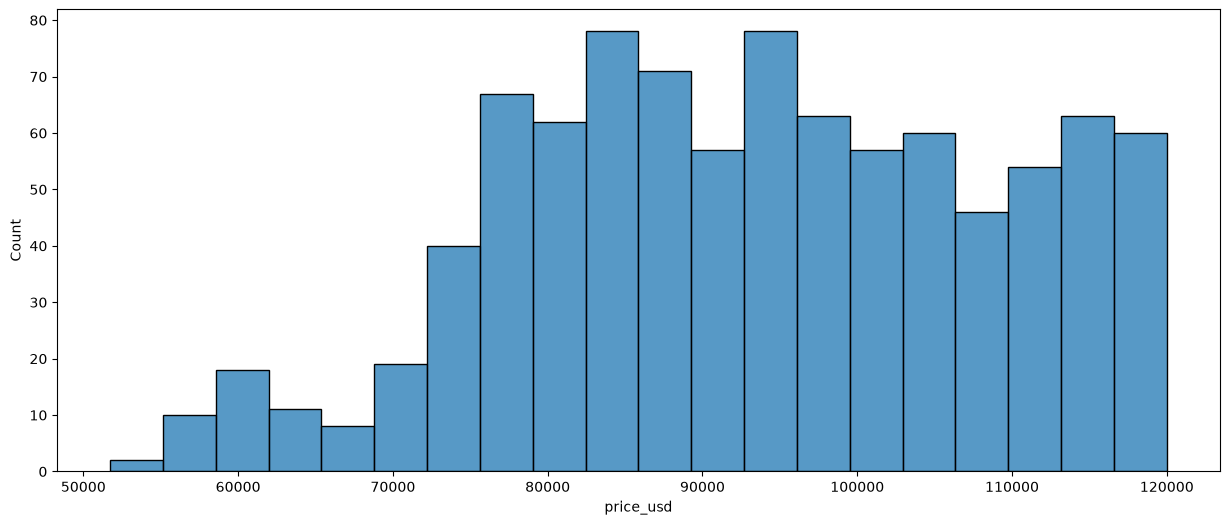

In [70]:
# Порядок распределения цен

plt.figure(figsize=(15,6)) # создаем "полотно", уточняем размер
sns.histplot(data=dfr, # какой датафрейм используем
             x='price_usd', # какую переменную отрисовываем
             bins = 20, # на сколько ячеек разбиваем
             log_scale = False); # захотели использовать логарифмический масштаб (для очень больших диапазонов)

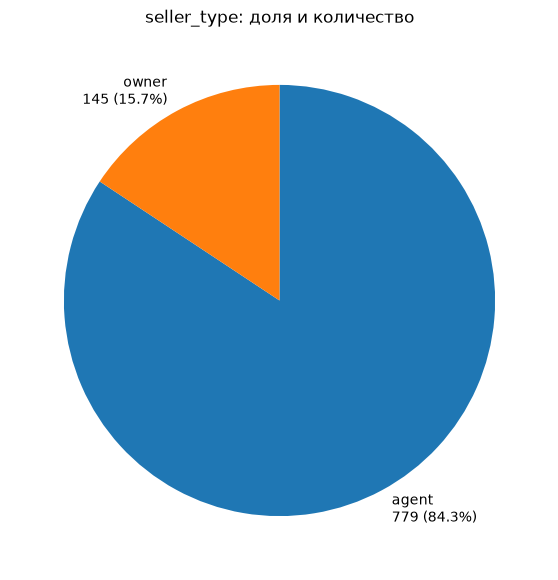

In [71]:
# Сравнение количества объявлений от агенств и собственника

plt.figure(figsize=(7, 7))

counts = dfr["seller_type"].value_counts(dropna=False)
total = counts.sum()

labels = counts.index.astype(str)
sizes = counts.values
percents = (sizes / total * 100).round(1)

plt.pie(
    sizes,
    labels=[f"{lab}\n{cnt} ({pct}%)" for lab, cnt, pct in zip(labels, sizes, percents)],
    startangle=90,
    counterclock=False
)

plt.title("seller_type: доля и количество")
plt.show()

In [72]:
# в данном датасете нет колонки "цена за м2", создадим её

dfr["price_per_m2"] = dfr["price_usd"] / dfr["area_total"].replace(0, np.nan)

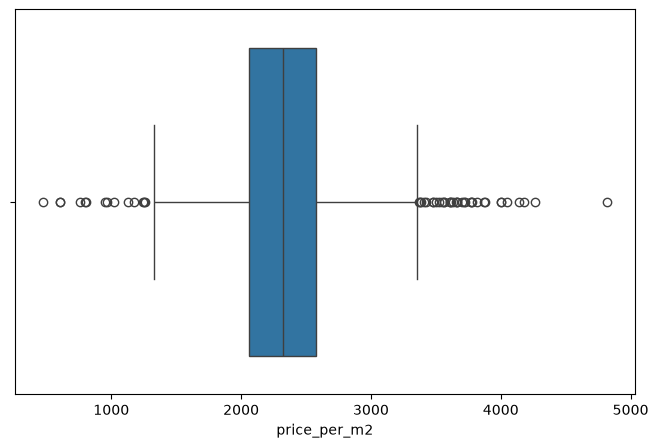

In [73]:
# разброс цен за м2

plt.figure(figsize=(8, 5))
sns.boxplot(data=dfr, x="price_per_m2")
plt.show()

#Подготовка к сопоставлению

In [74]:
dfy.head(2)

,price,price_usd,price_byn,price_per_m2,rooms,area_total,area_living,area_kitchen,address,street_name,house_number,metro_station,building_year,repair_state,agency_name,created_at,updated_at
0,110250,110250,333903,2250,1,49.0,49.0,NaN,Минск Лосика ул. 47,Лосика ул.,47.0,NaN,2026,8.0,owner,2026-07-13T18:05:25+03:00,2026-09-01T16:46:06+03:00
1,107000,107000,324060,2383,1,44.9,18.0,NaN,Минск Пташука ул. 1,Пташука ул.,1.0,NaN,2017,2.0,owner,2026-08-17T11:22:29+03:00,2026-09-15T09:49:15+03:00


In [75]:
dfr.head(2)

,price_amount,price_currency,price_usd,price_byn,number_of_rooms,floor,number_of_floors,area_total,area_living,area_kitchen,address,user_address,seller_type,created_at,last_time_up,price_per_m2
0,291403.0,BYN,96217.06,291403.0,1,3,22,31.3,24.2,NaN,"Минск, Братская ул. 8","Минск, Братская ул. 8",agent,2026-08-22T14:55:00+03:00,2026-09-15T11:15:09+03:00,3074.027476
1,118000.0,USD,118000.00,357374.8,2,6,10,53.3,31.8,9.2,"Минск, улица Сергея Есенина, 117","Минск, улица Сергея Есенина, 117",owner,2026-09-14T20:27:53+03:00,2026-09-14T20:27:53+03:00,2213.883677


In [76]:
# Удаляем столбцы, которых нет в одном из датасетов

dfy = dfy.drop(columns=['price', 'price_byn', 'street_name', 'house_number', 'repair_state', 'metro_station', 'building_year'])
dfr = dfr.drop(columns=['price_amount', 'price_currency', 'price_byn'])

In [77]:
# переименовываем колонки

dfr = dfr.rename(columns={
    "number_of_rooms": "rooms",
    "seller_type": "agency_name",
    "last_time_up": "updated_at"
})

# задаём новый порядок
new_order = [
    "price_usd",
    "price_per_m2",
    "rooms",
    "area_total",
    "area_living",
    "area_kitchen",
    "address",
    "user_address",
    "agency_name",
    "created_at",
    "updated_at"
]

# переставляем колонки
dfr = dfr[new_order]

Получили два одинаковых датасета по внешнему виду

In [78]:
dfy.head(1)

,price_usd,price_per_m2,rooms,area_total,area_living,area_kitchen,address,agency_name,created_at,updated_at
0,110250,2250,1,49.0,49.0,NaN,Минск Лосика ул. 47,owner,2026-07-13T18:05:25+03:00,2026-09-01T16:46:06+03:00


In [79]:
dfr.head(1)

,price_usd,price_per_m2,rooms,area_total,area_living,area_kitchen,address,user_address,agency_name,created_at,updated_at
0,96217.06,3074.027476,1,31.3,24.2,NaN,"Минск, Братская ул. 8","Минск, Братская ул. 8",agent,2026-08-22T14:55:00+03:00,2026-09-15T11:15:09+03:00


In [80]:
# Разбиваем колонку адрес на две с улицей и номером дома

extracted = dfy['address'].str.extract(r'Минск\s+(.+?)\s+ул\.\s+(\d+)')

dfy['street'] = extracted[0]
dfy['number'] = extracted[1].astype('Int64')

print(dfy)

      price_usd  price_per_m2  rooms  area_total  area_living  area_kitchen  \
0        110250          2250      1       49.00       49.000           NaN   
1        107000          2383      1       44.90       18.000           NaN   
2        105659          7547      2       42.40       27.300           NaN   
3        110282          6122      2       54.56       31.160         9.550   
4         57000          6989      1       24.70       18.200           NaN   
5        119000          8099      1       44.50       19.800        11.000   
6         89810          8095      1       33.60       17.900         7.200   
7         76933          7979      1       29.20       11.200         7.000   
8        116225          7364      2       47.80       30.100         6.400   
9         96918          9950      1       29.50       24.200           NaN   
10        77000          7265      1       32.10       19.900         5.000   
11       116302          8986      2       39.20    

In [81]:
# 1. Чистим запятые и лишние пробелы
dfr['address_clean'] = (
    dfr['user_address']
    .str.replace(',', ' ', regex=False)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# 2. Более гибкое извлечение
def extract_street_number(addr):
    if pd.isna(addr):
        return pd.Series([None, None])
    
    # Ищем паттерн: (улица/ул./вуліца) + название улицы + номер
    match = re.search(
        r'(?:улица|ул\.?|вуліца)\s+(.+?)\s+(\d+[А-Яа-яA-Za-z]*\s*[к/]?\s*\d*[А-Яа-яA-Za-z]*)',
        addr,
        flags=re.IGNORECASE
    )
    
    if match:
        street = match.group(1).strip()
        number = match.group(2).strip()
        return pd.Series([street, number])
    
    # Запасной вариант: просто берём последние 1-2 слова как номер, остальное как улицу
    parts = addr.split()
    if len(parts) >= 2 and re.search(r'\d', parts[-1]):
        number = parts[-1]
        street = ' '.join(parts[:-1])
        # Убираем "Минск", "Minsk", "Беларусь" если они остались
        street = re.sub(r'^(Минск|Minsk|Беларусь)\s+', '', street, flags=re.IGNORECASE)
        return pd.Series([street, number])
    
    return pd.Series([None, None])

dfr[['street', 'number']] = dfr['address_clean'].apply(extract_street_number)

# Смотрим результат
print(dfr[['address', 'street', 'number']].head(15))
print("\nКоличество распознанных строк:", dfr['street'].notna().sum())
print("Не распознанные:")
print(dfr[dfr['street'].isna()][['address']].head(10))

                                              address          street number
0                               Минск, Братская ул. 8    Братская ул.      8
1                    Минск, улица Сергея Есенина, 117  Сергея Есенина    117
2                    Минск, улица Мирошниченко, 16 к2    Мирошниченко  16 к2
3   Боровлянский сельский Совет, Боровляны, улица ...   40 лет Победы     35
4                     Minsk, вуліца Міхаіла Савіцкага             NaN    NaN
5                           Минск, Тарханова ул. 13ка   Тарханова ул.   13ка
6                             Минск, Уборевича ул. 36   Уборевича ул.     36
7                            Минск, улица Семашко, 4Б         Семашко     4Б
8                     Минск, улица Сергея Есенина, 28  Сергея Есенина     28
9                          Минск, Старый Аэропорт пл.             NaN    NaN
10                         Минск, Старый Аэропорт пл.             NaN    NaN
11                         Минск, Старый Аэропорт пл.             NaN    NaN

Сопоставление

In [82]:
# ============================================
# 1. Подготовка данных (если ещё не сделано)
# ============================================

# Убедимся, что ключевые колонки есть и приведены к нормальному виду
for df in [dfy, dfr]:
    # Приводим числовые поля
    for col in ['rooms', 'area_total', 'area_living']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # street и number делаем строками и убираем лишние пробелы
    if 'street' in df.columns:
        df['street'] = df['street'].astype(str).str.strip().str.lower()
    if 'number' in df.columns:
        df['number'] = df['number'].astype(str).str.strip().str.lower()

# ============================================
# 2. Функция сопоставления
# ============================================

def find_matches(dfy, dfr):
    matches = []
    
    # Проходим по каждой строке из dfy
    for idx_y, row_y in dfy.iterrows():
        # Базовые условия (обязательные)
        mask = (
            (dfr['rooms'] == row_y['rooms']) &
            (dfr['area_total'] == row_y['area_total']) &
            (dfr['area_living'] == row_y['area_living'])
        )
        
        candidates = dfr[mask]
        
        if candidates.empty:
            continue
        
        # Дополнительная проверка по street и number (если они есть)
        for idx_r, row_r in candidates.iterrows():
            street_match = True
            number_match = True
            
            # Проверяем street только если оба значения не пустые
            if pd.notna(row_y.get('street')) and pd.notna(row_r.get('street')):
                if str(row_y['street']).strip() != '' and str(row_r['street']).strip() != '':
                    street_match = (row_y['street'] == row_r['street'])
            
            # Проверяем number только если оба значения не пустые
            if pd.notna(row_y.get('number')) and pd.notna(row_r.get('number')):
                if str(row_y['number']).strip() != '' and str(row_r['number']).strip() != '':
                    number_match = (row_y['number'] == row_r['number'])
            
            # Если street/number совпали (или данных недостаточно) — считаем совпадением
            if street_match and number_match:
                match_row = {
                    # Индексы для удобства
                    'dfy_index': idx_y,
                    'dfr_index': idx_r,
                    
                    # Ключевые поля
                    'rooms': row_y['rooms'],
                    'area_total': row_y['area_total'],
                    'area_living': row_y['area_living'],
                    'street_y': row_y.get('street'),
                    'number_y': row_y.get('number'),
                    'street_r': row_r.get('street'),
                    'number_r': row_r.get('number'),
                    
                    # Можно добавить другие важные колонки
                    'address_y': row_y.get('address'),
                    'address_r': row_r.get('address'),
                    'price_y': row_y.get('price_usd'),      # если есть
                    'price_r': row_r.get('price_usd'),
                }
                matches.append(match_row)
    
    return pd.DataFrame(matches)

# ============================================
# 3. Запускаем сопоставление
# ============================================

matched = find_matches(dfy, dfr)

print(f"Найдено совпадений: {len(matched)}")
print(matched.head(10))

# ============================================
# 4. Сохраняем в Excel
# ============================================

matched.to_excel('matched_objects.xlsx', index=False)
print("\nФайл сохранён: matched_objects.xlsx")

Найдено совпадений: 184
   dfy_index  dfr_index  rooms  area_total  area_living      street_y  \
0         47        851      2        51.0         34.4           NaN   
1         80         38      2        49.7         34.4           NaN   
2        519         46      1        39.8         17.2      чичурина   
3        834        605      1        42.8         27.3    руссиянова   
4        838         58      2        63.3         39.4  партизанская   
5        848        781      1        32.2         19.0  калиновского   
6        850        313      1        36.9         17.3       рафиева   
7        889        750      1        31.2         15.4       казинца   
8        896        669      1        30.7         19.0    одоевского   
9        934        122      2        49.4         34.2           NaN   

  number_y                street_r number_r                         address_y  \
0      NaN  проспект рокоссовского      129    Минск Рокоссовского просп. 129   
1      NaN

In [83]:
# Количество совпадений

matched = matched.copy()

tol = 0.005  # 0.5%
diff = (matched["price_y"] - matched["price_r"]).abs()
rel_diff = diff / matched["price_r"].abs()

same_price = matched.loc[rel_diff <= tol]
diff_df = matched.loc[rel_diff > tol]

print("Совпадений (±0.5%):", len(same_price))
print(same_price[["price_y","price_r"]].head(10))

# для несовпавших суммы и разница
sum_y = diff_df["price_y"].sum()
sum_r = diff_df["price_r"].sum()
diff_sum = sum_y - sum_r

print("Сумма price_y (несовпавшие):", sum_y)
print("Сумма price_r (несовпавшие):", sum_r)
print("Разница (price_y - price_r):", diff_sum)

Совпадений (±0.5%): 140
    price_y    price_r
0     93500   93500.00
1     99023   99022.65
2     94763   94763.26
3    102027  102027.34
4     61084   61084.33
5     77500   77500.00
6     87900   87900.00
7     75000   75000.00
9    106653  106653.24
11   112000  112000.00
Сумма price_y (несовпавшие): 3790086
Сумма price_r (несовпавшие): 3995593.7999999993
Разница (price_y - price_r): -205507.79999999935
